In [1]:
import numpy as np, xgboost as xgb, joblib, matplotlib.pyplot as plt, seaborn as sns, os
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
os.makedirs('../reports/figures', exist_ok=True)
x_test_b = np.load('../data/processed/x_test.npy')
y_test_b = np.load('../data/processed/y_test_binary.npy')
x_test_m = np.load('../data/processed/x_test.npy')
y_test_m = np.load('../data/processed/y_test_multi.npy')
model_binary = joblib.load('../models/model_binary.pkl')
model_multi  = joblib.load('../models/model_multiclass.pkl')
print(f"x_test_b: {x_test_b.shape}")
print(f"y_test_b: {y_test_b.shape}")
print(f"y_test_m: {y_test_m.shape}")
print("Données et modèles chargés")

x_test_b: (22544, 134)
y_test_b: (22544,)
y_test_m: (22544,)
Données et modèles chargés


 Accuracy Modèle 1 (seuil=0.3) : 85.88%


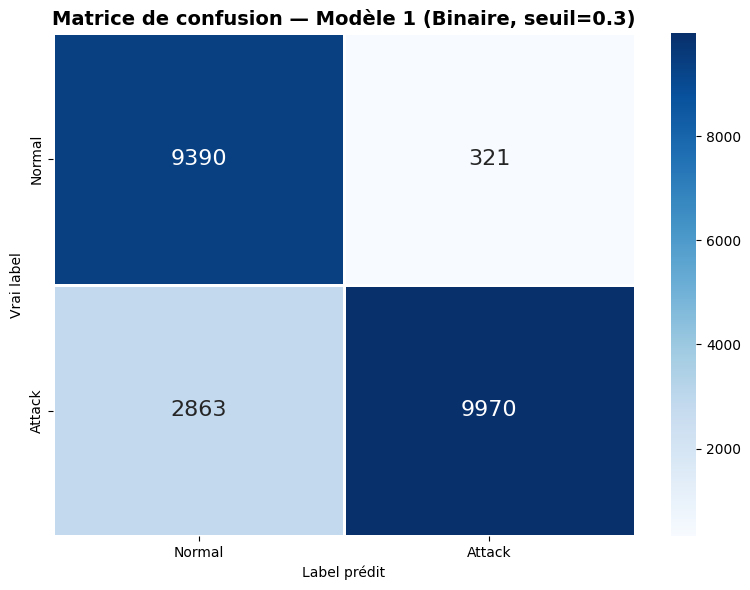

              precision    recall  f1-score   support

      Normal       0.77      0.97      0.86      9711
      Attack       0.97      0.78      0.86     12833

    accuracy                           0.86     22544
   macro avg       0.87      0.87      0.86     22544
weighted avg       0.88      0.86      0.86     22544



In [2]:
dtest = xgb.DMatrix(x_test_b)
preds_b = model_binary.predict(dtest)
SEUIL = 0.3
pred_b = (preds_b > SEUIL).astype(int)
acc_b = accuracy_score(y_test_b, pred_b)
print(f" Accuracy Modèle 1 (seuil={SEUIL}) : {acc_b*100:.2f}%")
cm1 = confusion_matrix(y_test_b, pred_b)
plt.figure(figsize=(8,6))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'],
    annot_kws={"size":16}, linewidths=1, linecolor='white')
plt.title(f'Matrice de confusion — Modèle 1 (Binaire, seuil={SEUIL})', fontsize=14, fontweight='bold')
plt.xlabel('Label prédit'); plt.ylabel('Vrai label')
plt.tight_layout(); plt.savefig('../reports/figures/cm_binaire.png',dpi=150,bbox_inches='tight'); plt.show()
print(classification_report(y_test_b, pred_b, target_names=['Normal','Attack']))

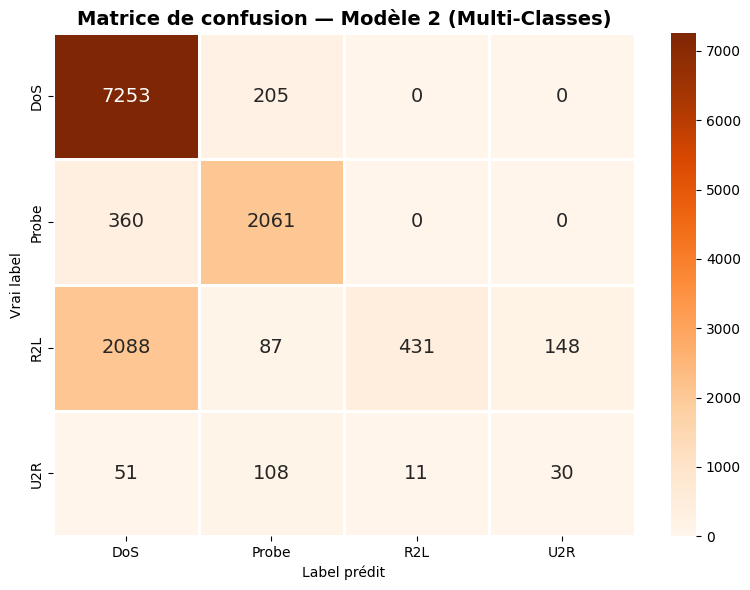

In [3]:
preds_m = preds_m = model_multi.predict(dtest)
pred_m = np.argmax(preds_m, axis=1)
mask_att = y_test_m != 0  # attaques uniquement
y_att = y_test_m[mask_att] - 1  # 0=DoS, 1=Probe, 2=R2L, 3=U2R
p_att = pred_m[mask_att].copy()
p_att[p_att==0] = 1  # si prédit Normal, fallback DoS (plus fréquent)
p_att = p_att - 1
cm2 = confusion_matrix(y_att, p_att, labels=[0,1,2,3])
plt.figure(figsize=(8,6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['DoS','Probe','R2L','U2R'], yticklabels=['DoS','Probe','R2L','U2R'],
    annot_kws={"size":14}, linewidths=1, linecolor='white')
plt.title('Matrice de confusion — Modèle 2 (Multi-Classes)', fontsize=14, fontweight='bold')
plt.xlabel('Label prédit'); plt.ylabel('Vrai label')
plt.tight_layout(); plt.savefig('../reports/figures/cm_multiclass.png',dpi=150,bbox_inches='tight'); plt.show()

🎯 Accuracy Système IDS Complet : 80.94%


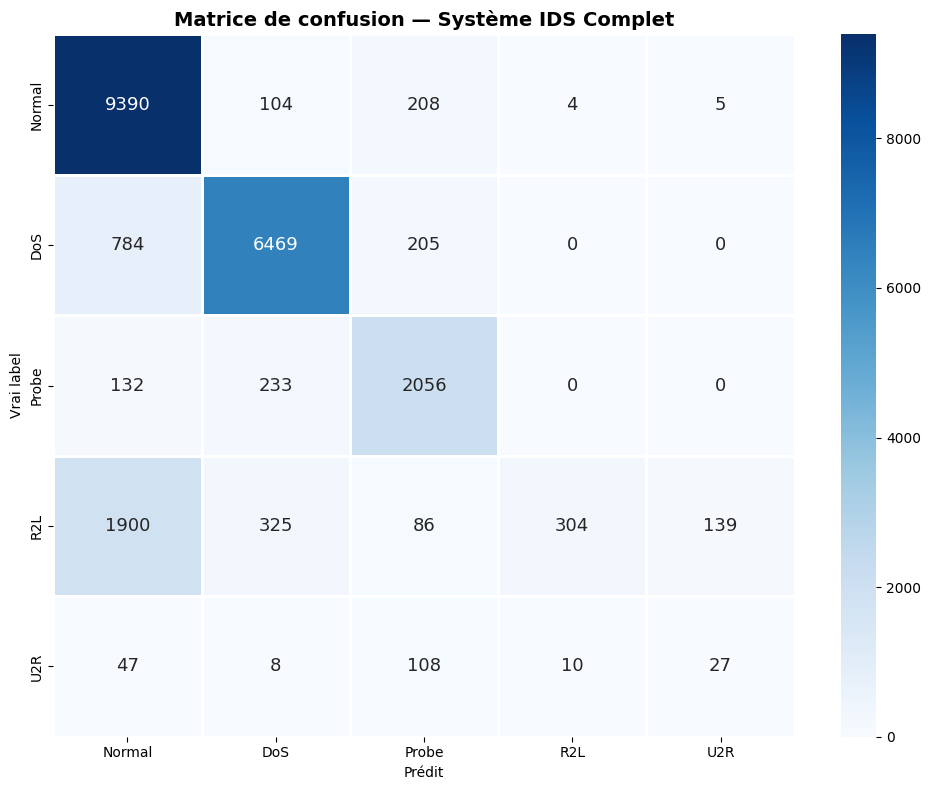

              precision    recall  f1-score   support

      Normal       0.77      0.97      0.86      9711
         DoS       0.91      0.87      0.89      7458
       Probe       0.77      0.85      0.81      2421
         R2L       0.96      0.11      0.20      2754
         U2R       0.16      0.14      0.15       200

    accuracy                           0.81     22544
   macro avg       0.71      0.59      0.58     22544
weighted avg       0.83      0.81      0.77     22544


 SYSTÈME IDS COMPLET — Évaluation terminée !


In [4]:
def cascade_predict(X, mb, mm, seuil=0.3):
    dX = xgb.DMatrix(X)
    yb = (mb.predict(dX) > seuil).astype(int)
    ym = np.argmax(mm.predict(dX), axis=1)
    y_final = np.zeros(len(X), dtype=int)
    idx_att = np.where(yb==1)[0]
    y_final[idx_att] = ym[idx_att]
    y_final[(yb==1) & (ym==0)] = 1
    return y_final

y_pred_cascade = cascade_predict(x_test_m, model_binary, model_multi, seuil=0.3)
acc_c = accuracy_score(y_test_m, y_pred_cascade)
print(f"🎯 Accuracy Système IDS Complet : {acc_c*100:.2f}%")
cm3 = confusion_matrix(y_test_m, y_pred_cascade, labels=[0,1,2,3,4])
labels5 = ['Normal','DoS','Probe','R2L','U2R']
plt.figure(figsize=(10,8))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels5, yticklabels=labels5,
    annot_kws={"size":13}, linewidths=1, linecolor='white')
plt.title('Matrice de confusion — Système IDS Complet', fontsize=14, fontweight='bold')
plt.xlabel('Prédit'); plt.ylabel('Vrai label')
plt.tight_layout(); plt.savefig('../reports/figures/cm_ids_complet.png',dpi=150,bbox_inches='tight'); plt.show()
print(classification_report(y_test_m, y_pred_cascade, target_names=labels5))
print("\n SYSTÈME IDS COMPLET — Évaluation terminée !")